# DSA 504 — Homework 2
## Cleaning and Visualizing Retail Sales

**Assigned:** Class 7 (Wednesday, Sep 23)
**Due:** Before Class 9 (Wednesday, Sep 30)
**Worth:** 1 of 6 homework assignments (homework is 50% of your final grade, split evenly across all 6)

---

### Instructions

- Use `retail_sales.csv` — the **original, uncleaned** file (not `retail_sales_clean.csv`). This assignment asks you to do the cleaning yourself, from scratch.
- Fill in each `# TODO` code cell below. Do not delete the cells or reorder them.
- A few cells ask a **short written question or judgment call** — answer these directly in the markdown cell provided.
- This assignment builds directly on Classes 6–9: missing values, duplicates, string/regex cleaning, dates, and visualization (matplotlib + seaborn).
- **AI use:** if you use an AI tool for help on any part of this assignment, briefly note where and how in the markdown cell at the very bottom of this notebook, per the course AI-use policy in the syllabus.

### Submission — two required steps
1. Save this completed notebook inside a folder called `hw2/` in your `dsa504-coursework` GitHub Classroom repository, then commit and push:
```
git add hw2/
git commit -m "Complete HW2"
git push
```
2. Upload this completed `.ipynb` file directly to the HW2 assignment on Brightspace, and paste the direct link to your `hw2/` folder into the submission comments box (e.g., `github.com/your-username/dsa504-coursework/tree/main/hw2`).

**Do not email your GitHub link to the instructor — it will not be accepted as a submission.**

### Grading breakdown
| Section | Weight |
|---|---|
| Part 1 — Detect Missing Values & Duplicates | 15% |
| Part 2 — Clean Missing Values & Duplicates | 20% |
| Part 3 — Clean the Category Column | 25% |
| Part 4 — Fix Date Type & Extract Features | 15% |
| Part 5 — Visualize the Cleaned Data | 20% |
| Part 6 — Written Reflection | 5% |


In [14]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv("retail_sales.csv")
sales.head()


,date,store,category,units_sold,revenue
0,2025-04-22,Rome,Toys,25.0,402.50
1,2025-04-12,Syracuse,electronics,38.0,3154.00
2,2025-12-21,Utica,home goods,42.0,1299.06
3,2025-02-11,Syracuse,Electronics,60.0,5114.40
4,2025-04-10,Syracuse,toys,10.0,147.10


---
## Part 1 — Detect Missing Values & Duplicates (15%)


**1a.** Print how many missing values exist in each column, and what percentage of total rows that represents for `units_sold` and `revenue` specifically.


In [15]:
# TODO 1a
# Print missing values per column and percentages for units_sold and revenue
missing_counts = sales.isnull().sum()
print("Missing values per column:")
print(missing_counts)

total_rows = len(sales)
print(f"\nPercentage of missing values:")
print(f"units_sold: {(missing_counts['units_sold'] / total_rows) * 100:.2f}%")
print(f"revenue: {(missing_counts['revenue'] / total_rows) * 100:.2f}%")


Missing values per column:
date           0
store          0
category       0
units_sold    60
revenue       60
dtype: int64

Percentage of missing values:
units_sold: 1.49%
revenue: 1.49%


**1b.** Print how many exact duplicate rows exist in the dataset.


In [16]:
# TODO 1b
# Print the number of exact duplicate rows
duplicate_count = sales.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")


Number of exact duplicate rows: 25


---
## Part 2 — Clean Missing Values & Duplicates (20%)


**2a.** Fill missing `units_sold` values with the column's median. Fill missing `revenue` values with the column's median as well. Confirm afterward that both columns have zero missing values.


In [17]:
# TODO 2a
# Fill missing values with medians and confirm zero missing values
sales["units_sold"] = sales["units_sold"].fillna(sales["units_sold"].median())
sales["revenue"] = sales["revenue"].fillna(sales["revenue"].median())

print("Missing values after filling:")
print(sales[["units_sold", "revenue"]].isnull().sum())


Missing values after filling:
units_sold    0
revenue       0
dtype: int64


**2b.** Remove exact duplicate rows from the dataset. Print the row count before and after.


In [18]:
# TODO 2b
# Remove duplicate rows and print row counts before and after
print(f"Row count before removing duplicates: {len(sales)}")
sales = sales.drop_duplicates()
print(f"Row count after removing duplicates: {len(sales)}")


Row count before removing duplicates: 4039
Row count after removing duplicates: 4014


**2c. Written question:** Why might filling `units_sold` with 0 instead of the median have been a worse choice for this dataset? Answer in 1–2 sentences.

*Your answer here:*


Filling missing units_sold with $0$ instead of the median would artificially pull down the distribution and skew aggregate metrics like totals and averages. Using the median preserves the central tendency of typical transactions without introducing false zero-quantity records that distort downstream analysis.

---
## Part 3 — Clean the Category Column (25%)


**3a.** Print the sorted list of unique values currently in the `category` column, and how many distinct values there are.


In [19]:
# TODO 3a
# Print sorted unique values and count of distinct values in category
unique_categories = sorted(sales["category"].dropna().unique())
print("Unique categories:", unique_categories)
print("Count of distinct values:", len(unique_categories))


Unique categories: ['Cloth ing', 'Clothing', 'ELECTRONICS', 'Electronics', 'Groceries', 'Home Goods', 'Home_Goods', 'Toys', 'clothing', 'electronics', 'groceries', 'home goods', 'toys']
Count of distinct values: 13


**3b.** Clean the `category` column into a new column called `category_clean`, using the same three-step approach from Class 7: lowercase and strip whitespace, then use a regex to normalize underscores/extra spaces into single spaces, then fix any remaining typos with an explicit mapping. Print the sorted unique values of `category_clean` — it should show **exactly 5** categories.


In [28]:
# TODO 3b
# Clean category column into category_clean
sales["category_clean"] = (
    sales["category"]
    .str.lower()
    .str.strip()
    .str.replace(r"[\s_]+", " ", regex=True)
)

# Fix the remaining typo where "cloth ing" has an extra space inside
sales["category_clean"] = sales["category_clean"].replace({"cloth ing": "clothing"})

print("Sorted unique values of category_clean:")
print(sorted(sales["category_clean"].unique()))


Sorted unique values of category_clean:
['clothing', 'electronics', 'groceries', 'home goods', 'toys']


**3c.** Using your cleaned `category_clean` column, compute total revenue per category. Compare this to what you would have gotten using the original, uncleaned `category` column. Are the two results different? Why?


In [29]:
# TODO 3c
# Compare total revenue per category: clean vs. uncleaned
revenue_clean = sales.groupby("category_clean")["revenue"].sum()
revenue_orig = sales.groupby("category")["revenue"].sum()

print("Revenue by category_clean:")
print(revenue_clean)
print("\nRevenue by original category:")
print(revenue_orig)


Revenue by category_clean:
category_clean
clothing       1261973.62
electronics    2826166.86
groceries       705737.66
home goods      970438.49
toys            315535.71
Name: revenue, dtype: float64

Revenue by original category:
category
Cloth ing      410936.16
Clothing       387017.99
ELECTRONICS    871570.51
Electronics    966411.07
Groceries      367145.73
Home Goods     323341.47
Home_Goods     318960.22
Toys           152744.19
clothing       464019.47
electronics    988185.28
groceries      338591.93
home goods     328136.80
toys           162791.52
Name: revenue, dtype: float64


---
## Part 4 — Fix Date Type & Extract Features (15%)


**4a.** Check the current data type of the `date` column, then convert it to a proper datetime type.


In [22]:
# TODO 4a
# Check current data type and convert date column
print("Current data type:", sales["date"].dtype)
sales["date"] = pd.to_datetime(sales["date"])
print("Converted data type:", sales["date"].dtype)


Current data type: str
Converted data type: datetime64[us]


**4b.** Using the converted `date` column, create two new columns: `month_name` (the full month name) and `day_of_week` (the full weekday name).


In [23]:
# TODO 4b
# Extract month name and day of the week
sales["month_name"] = sales["date"].dt.month_name()
sales["day_of_week"] = sales["date"].dt.day_name()
sales[["date", "month_name", "day_of_week"]].head()


,date,month_name,day_of_week
0,2025-04-22,April,Tuesday
1,2025-04-12,April,Saturday
2,2025-12-21,December,Sunday
3,2025-02-11,February,Tuesday
4,2025-04-10,April,Thursday


---
## Part 5 — Visualize the Cleaned Data (20%)

Using your cleaned dataset (duplicates removed, missing values filled, `category_clean` in place, `date` converted), create **at least 3 charts**:


**5a.** One **matplotlib** line or bar chart of your choice (e.g., total revenue over time, or total revenue by store). Include a title and axis labels.


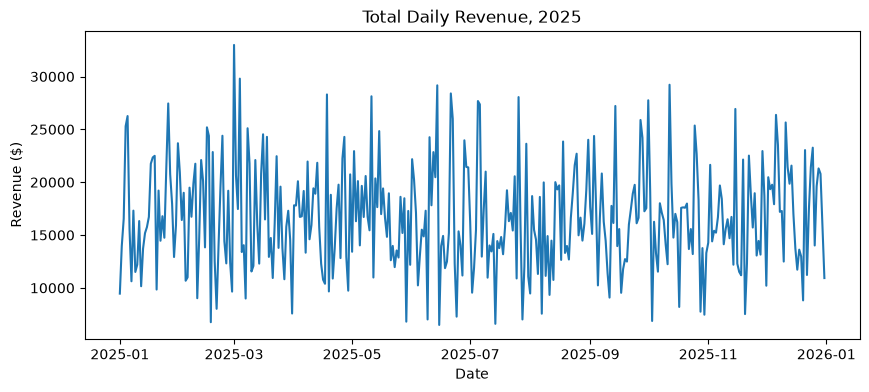

In [24]:
# TODO 5a
# Matplotlib line chart of total daily revenue over time
daily_revenue = sales.groupby("date")["revenue"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily_revenue.index, daily_revenue.values)
ax.set_title("Total Daily Revenue, 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
plt.show()


**5b.** One **seaborn box plot** comparing `revenue` across your cleaned categories (`category_clean`).


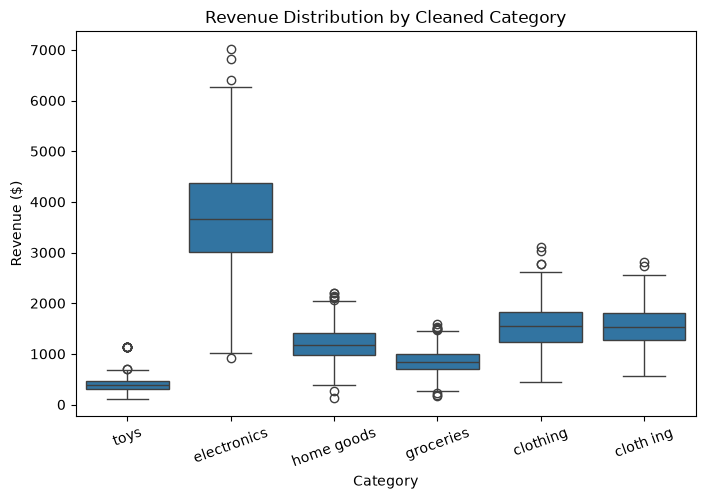

In [25]:
# TODO 5b
# Seaborn box plot comparing revenue across cleaned categories
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sales, x="category_clean", y="revenue", ax=ax)
ax.set_title("Revenue Distribution by Cleaned Category")
ax.set_xlabel("Category")
ax.set_ylabel("Revenue ($)")
ax.tick_params(axis="x", rotation=20)
plt.show()


**5c.** One more **seaborn** chart of your choice that uses the `hue` parameter to show a third variable (for example, a histogram or scatter plot colored by `store` or `category_clean`).


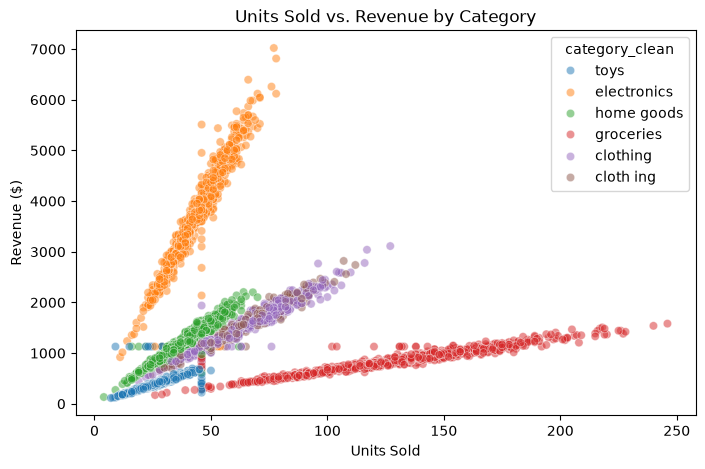

In [26]:
# TODO 5c
# Seaborn scatter plot of units_sold vs. revenue colored by category_clean
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sales, x="units_sold", y="revenue", hue="category_clean", alpha=0.5, ax=ax)
ax.set_title("Units Sold vs. Revenue by Category")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Revenue ($)")
plt.show()


---
## Part 6 — Written Reflection (5%)

Answer in 2–3 sentences, in this markdown cell:

**Question:** Pick one chart you made in Part 5. If you had made this same chart using the *original, uncleaned* data instead, how would it likely have looked different or been misleading?

*Your answer here:*


If we had used the uncleaned category column for the box plot (Part 5b), formatting inconsistencies and typos would have generated redundant, separate boxes for the same underlying categories. This would have cluttered the visualization and misrepresented the actual distribution of revenue per category.

---
### AI Use Disclosure

*If you used an AI tool (Claude, ChatGPT, GitHub Copilot, etc.) for any part of this assignment, briefly state where and how below, and how you verified the result. If you did not use any AI tool, write "No AI tools were used."*

*Your answer here:*


Gemini AI was used to clarify questions regarding code syntax and verify the logic for the data cleaning and visualization steps.